<a href="https://colab.research.google.com/github/emiliomartineziteso/sim-mat/blob/main/Tarea_1_1_Optimizaci%C3%B3n_escalar_con_SymPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimización escalar con SymPy: criterio conocido

Para la siguientes funciones encuentre los puntos críticos, grafique y diga si éste se trata de un máximo o mínimo, local o global.

1. $f(x)=x+\frac{1}{x^2}$

Puntos críticos: [2**(1/3), -2**(1/3)/2 - 2**(1/3)*sqrt(3)*I/2, -2**(1/3)/2 + 2**(1/3)*sqrt(3)*I/2]
f(2**(1/3)) = 3*2**(1/3)/2  - segunda derivada: 3*2**(2/3)/2
f(-2**(1/3)/2 - 2**(1/3)*sqrt(3)*I/2) = -2**(1/3)/2 - 2**(1/3)*sqrt(3)*I/2 + (-2**(1/3)/2 - 2**(1/3)*sqrt(3)*I/2)**(-2)  - segunda derivada: 6/(-2**(1/3)/2 - 2**(1/3)*sqrt(3)*I/2)**4
f(-2**(1/3)/2 + 2**(1/3)*sqrt(3)*I/2) = -2**(1/3)/2 + (-2**(1/3)/2 + 2**(1/3)*sqrt(3)*I/2)**(-2) + 2**(1/3)*sqrt(3)*I/2  - segunda derivada: 6/(-2**(1/3)/2 + 2**(1/3)*sqrt(3)*I/2)**4


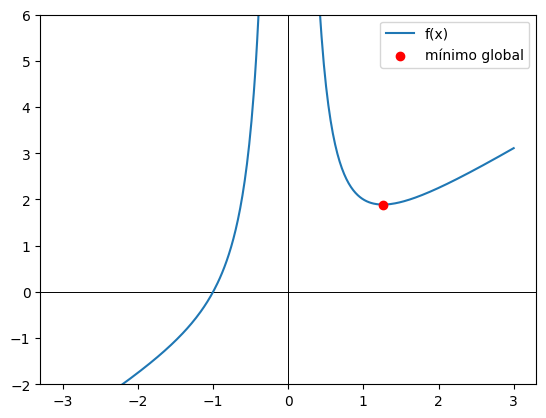

In [3]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

# Definición de la variable y función
x = sp.symbols('x')
f = x + 1/x**2

# Derivadas
f_prime = sp.diff(f, x)
f_double = sp.diff(f_prime, x)

# Punto crítico
critical_points = sp.solve(sp.Eq(f_prime, 0), x)
print("Puntos críticos:", critical_points)

# Evaluación en el punto crítico
for cp in critical_points:
    print(f"f({cp}) =", f.subs(x, cp), " - segunda derivada:", f_double.subs(x, cp))

# Gráfica
f_lambd = sp.lambdify(x, f, 'numpy')
xx = np.linspace(-3, 3, 400)
xx = xx[xx != 0]  # quitar x=0

plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)

plt.plot(xx, f_lambd(xx), label="f(x)")
plt.scatter([float(critical_points[0])], [float(f.subs(x, critical_points[0]))],
            color="red", zorder=5, label="mínimo global")

plt.ylim(-2, 6)
plt.legend()
plt.show()


Este es un minimo global

2. $f(x)=1260+117x-9x^2$

Punto crítico: 13/2
f(cp) = 1640.25
f''(x) = -18


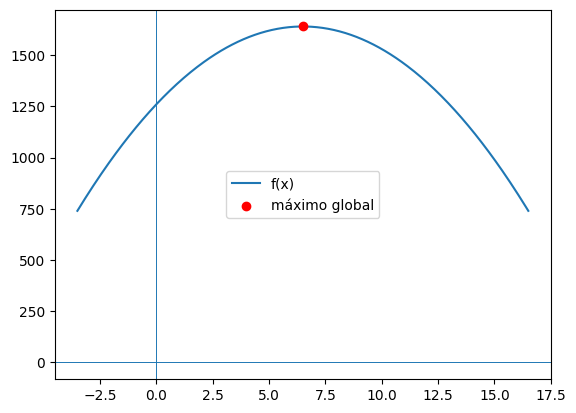

In [4]:
x = sp.symbols('x')
f = 1260 + 117*x - 9*x**2

f_prime = sp.diff(f, x)
f_double = sp.diff(f_prime, x)
cp = sp.solve(sp.Eq(f_prime, 0), x)[0]
f_cp = float(f.subs(x, cp))

print("Punto crítico:", cp)
print("f(cp) =", f_cp)
print("f''(x) =", f_double)

f_num = sp.lambdify(x, f, 'numpy')
xx = np.linspace(cp-10, cp+10, 400)
plt.plot(xx, f_num(xx), label='f(x)')
plt.scatter([float(cp)], [f_cp], color='red', zorder=5, label='máximo global')
plt.axhline(0, linewidth=0.7)
plt.axvline(0, linewidth=0.7)
plt.legend()
plt.show()


**3**. $f(x)=5+x+\frac{4}{x}$, para $x>0$

f(x) simplificada = 5*x + 5
f'(x) = 5
f''(x) = 0


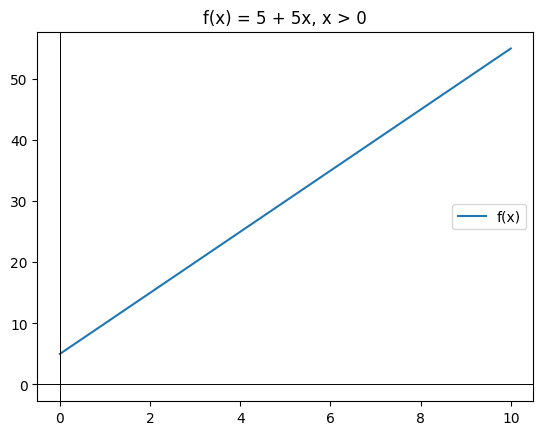

In [5]:
x = sp.symbols('x', positive=True)
f = 5 + x + 4*x   # se simplifica a 5 + 5x

f_prime = sp.diff(f, x)
f_double = sp.diff(f_prime, x)

print("f(x) simplificada =", sp.simplify(f))
print("f'(x) =", f_prime)
print("f''(x) =", f_double)

f_num = sp.lambdify(x, f, 'numpy')
xx = np.linspace(0, 10, 400)  # dominio x>0
yy = f_num(xx)

plt.plot(xx, yy, label="f(x)")
plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)
plt.title("f(x) = 5 + 5x, x > 0")
plt.legend()
plt.show()


4. $f(x)=\frac{15x}{2}\sqrt{\frac{x}{x-30}}$

f'(x) = 15*x**2/(2*sqrt(x - 30)) + 30*x*sqrt(x - 30)
f''(x) = -15*x**2/(4*(x - 30)**(3/2)) + 30*x/sqrt(x - 30) + 30*sqrt(x - 30)
Todos los puntos críticos: [0, 24]
Puntos críticos en el dominio: []


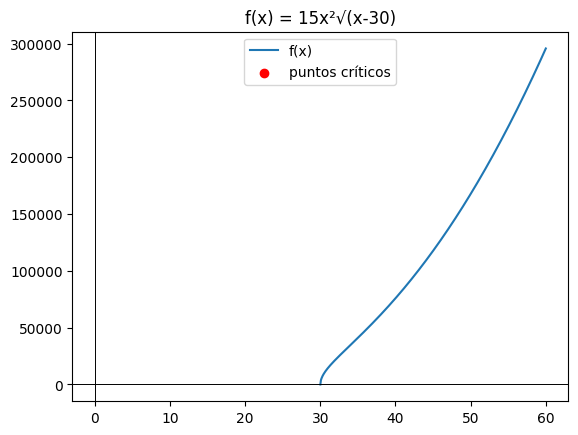

In [7]:
x = sp.symbols('x', real=True)
f = 15*x**2*sp.sqrt(x - 30)

f_prime = sp.diff(f, x)
f_double = sp.diff(f_prime, x)
criticos = sp.solve(sp.Eq(f_prime, 0), x)

print("f'(x) =", f_prime)
print("f''(x) =", f_double)
print("Todos los puntos críticos:", criticos)

criticos_validos = [c for c in criticos if c.is_real and c >= 30]
print("Puntos críticos en el dominio:", criticos_validos)

f_num = sp.lambdify(x, f, 'numpy')
xx = np.linspace(30, 60, 400)
yy = f_num(xx)

plt.plot(xx, yy, label="f(x)")
plt.scatter([float(c) for c in criticos_validos],
            [float(f.subs(x, c)) for c in criticos_validos],
            color="red", zorder=5, label="puntos críticos")
plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)
plt.title("f(x) = 15x²√(x-30)")
plt.legend()
plt.show()


5. $f(x)=6-2x+\sqrt{18-2x^2}$, para $-3\leq x\leq 3$

f'(x) = -2*x/sqrt(18 - 2*x**2) - 2
f''(x) = -4*x**2/(18 - 2*x**2)**(3/2) - 2/sqrt(18 - 2*x**2)
Todos los puntos críticos: [-sqrt(6)]
Puntos críticos en el dominio: [-sqrt(6)]


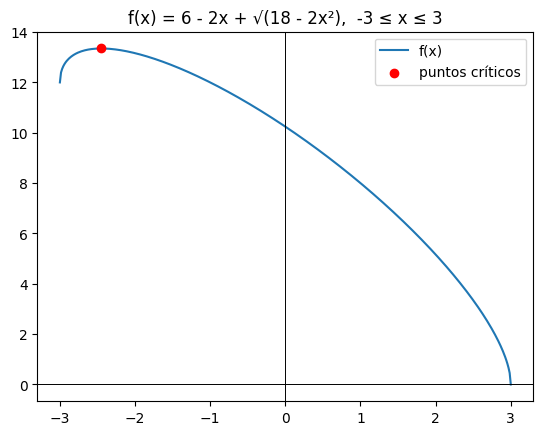

In [8]:
x = sp.symbols('x', real=True)
f = 6 - 2*x + sp.sqrt(18 - 2*x**2)

f_prime = sp.diff(f, x)
f_double = sp.diff(f_prime, x)
criticos = sp.solve(sp.Eq(f_prime, 0), x)

print("f'(x) =", f_prime)
print("f''(x) =", f_double)
print("Todos los puntos críticos:", criticos)

criticos_validos = []
for c in criticos:
    if c.is_real and -3 <= float(c) <= 3 and (18 - 2*float(c)**2) >= 0:
        criticos_validos.append(c)

print("Puntos críticos en el dominio:", criticos_validos)

f_num = sp.lambdify(x, f, 'numpy')
xx = np.linspace(-3, 3, 400)
yy = f_num(xx)

plt.plot(xx, yy, label="f(x)")
plt.scatter([float(c) for c in criticos_validos],
            [float(f.subs(x, c)) for c in criticos_validos],
            color="red", zorder=5, label="puntos críticos")
plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)
plt.title("f(x) = 6 - 2x + √(18 - 2x²),  -3 ≤ x ≤ 3")
plt.legend()
plt.show()


6. $f(x)=\frac{1}{4}x^4+\frac{1}{3}x^3-x^2$ en el intervalo $[-3,1.7]$

f'(x) = 56*x**3 + 39*x**2 - 2*x
f''(x) = 168*x**2 + 78*x - 2
Todos los puntos críticos: [0, -39/112 + sqrt(1969)/112, -sqrt(1969)/112 - 39/112]
Puntos críticos en el dominio: [0, -39/112 + sqrt(1969)/112, -sqrt(1969)/112 - 39/112]


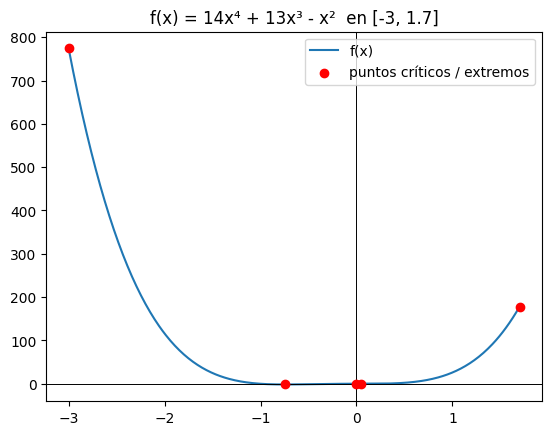

In [10]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x = sp.symbols('x', real=True)
f = 14*x**4 + 13*x**3 - x**2

f_prime = sp.diff(f, x)
f_double = sp.diff(f_prime, x)
criticos = sp.solve(sp.Eq(f_prime, 0), x)

print("f'(x) =", f_prime)
print("f''(x) =", f_double)
print("Todos los puntos críticos:", criticos)

criticos_validos = []
for c in criticos:
    if c.is_real and -3 <= float(c) <= 1.7:
        criticos_validos.append(c)

print("Puntos críticos en el dominio:", criticos_validos)

extremos = [-3, 1.7]
puntos_eval = criticos_validos + extremos

f_num = sp.lambdify(x, f, 'numpy')
xx = np.linspace(-3, 1.7, 400)
yy = f_num(xx)

plt.plot(xx, yy, label="f(x)")
plt.scatter([float(c) for c in puntos_eval],
            [float(f.subs(x, c)) for c in puntos_eval],
            color="red", zorder=5, label="puntos críticos / extremos")
plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)
plt.title("f(x) = 14x⁴ + 13x³ - x²  en [-3, 1.7]")
plt.legend()
plt.show()


7. $f(x)=100(1+\cos(x)\sin(x))$, para $x\in[0.\frac{\pi}{2}]$

f'(x) = -100*sin(x)**2 + 100*cos(x)**2
f''(x) = -400*sin(x)*cos(x)
Todos los puntos críticos: [-pi/4, pi/4]
Puntos críticos en el dominio: [pi/4]


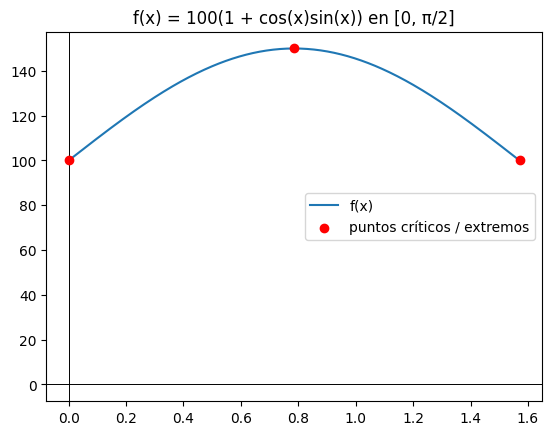

In [12]:
x = sp.symbols('x', real=True)
f = 100*(1 + sp.cos(x)*sp.sin(x))

f_prime = sp.diff(f, x)
f_double = sp.diff(f_prime, x)
criticos = sp.solve(sp.Eq(f_prime, 0), x)

print("f'(x) =", f_prime)
print("f''(x) =", f_double)
print("Todos los puntos críticos:", criticos)

criticos_validos = []
for c in criticos:
    if c.is_real and 0 <= float(c) <= float(sp.pi/2):
        criticos_validos.append(c)

print("Puntos críticos en el dominio:", criticos_validos)

extremos = [0, sp.pi/2]
puntos_eval = criticos_validos + extremos

f_num = sp.lambdify(x, f, 'numpy')
xx = np.linspace(0, np.pi/2, 400)
yy = f_num(xx)

plt.plot(xx, yy, label="f(x)")
plt.scatter([float(c) for c in puntos_eval],
            [float(f.subs(x, c)) for c in puntos_eval],
            color="red", zorder=5, label="puntos críticos / extremos")
plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)
plt.title("f(x) = 100(1 + cos(x)sin(x)) en [0, π/2]")
plt.legend()
plt.show()
